<a href="https://colab.research.google.com/github/JUANLUCIO93/Mineria_Datos_Libreria_UEA/blob/main/PROYECTO_FINAL_ANALISIS_DE_DATOS_DE_UN_SISTEMA_DE_UNA_LIBRERIA_COMERCIAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

#ANALISIS DE DATOS DE UN SISTEMA GESTION DE LIBRERIA COMERCIAL.

# 1. CARGA DE LIBRERÍAS Y DATOS DE FACTURACIÓN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv('facturacion_libreria.csv')
except:
    # Generación de dataset sintético representativo de ventas de librería (POS)
    np.random.seed(42)
    n = 6100
    df = pd.DataFrame({
        'id_factura': [f'FAC-{i:05d}' for i in range(1, n+1)],
        'id_cliente': np.random.choice([f'CLI-{i:04d}' for i in range(1, 1500)], n),
        'monto_facturado': np.round(np.random.exponential(scale=45, size=n) + 5, 2),
        'total_libros_comprados': np.random.randint(1, 10, size=n),
        'categoria_mas_comprada': np.random.choice(['Ficción', 'Libro Literatura', 'Libro Matematica', 'Ciencias Naturales', 'Libro dibujo Artistico'], n),
        'metodo_pago': np.random.choice(['Tarjeta_Credito', 'Efectivo', 'Transferencia'], n, p=[0.5, 0.3, 0.2]),
        'factura_electronica': np.random.choice([1, 0], n, p=[0.7, 0.3]),
        'dias_sin_comprar': np.random.randint(1, 180, size=n),
        'cliente_abandonó': np.random.choice([0, 1], n, p=[0.75, 0.25])
    })

print("Primeros 5 registros del Sistema de Facturación:")
df.head()

Primeros 5 registros del Sistema de Facturación:


,id_factura,id_cliente,monto_facturado,total_libros_comprados,categoria_mas_comprada,metodo_pago,factura_electronica,dias_sin_comprar,cliente_abandonó
0,FAC-00001,CLI-1127,10.73,4,Libro Literatura,Efectivo,1,29,0
1,FAC-00002,CLI-1460,43.26,6,Libro Literatura,Efectivo,1,97,1
2,FAC-00003,CLI-0861,18.35,7,Libro dibujo Artistico,Efectivo,1,74,1
3,FAC-00004,CLI-1295,78.36,6,Libro Matematica,Tarjeta_Credito,0,124,0
4,FAC-00005,CLI-1131,29.98,6,Libro Matematica,Efectivo,1,156,0


Primero  importé las librerías esenciales para el análisis de datos en Python, como Implementa un bloque **try-except** para intentar cargar el archivo real de ventas **facturacion_libreria.csv.** En caso de no encontrar el archivo local, ejecuta la generación automática de un conjunto de datos sintético (n = 6,100 registros) que simula las transacciones reales de un punto de venta (POS) de una librería comercial.

El comando df.head() despliega los primeros 5 registros de la base de datos de facturación. Cada columna cumple una función analítica dentro del modelo:

In [ ]:
# 2. EXPLORACIÓN Y DIAGNÓSTICO DE DATOS

print("--- Dimensión del Dataset ---")
print(f"Registros de facturas: {df.shape[0]} | Variables: {df.shape[1]}\n")

print("--- Porcentaje de Valores Nulos por Variable ---")
print(df.isnull().mean() * 100)

print("\n--- Registros Duplicados ---")
print(f"Total de facturas duplicadas: {df.duplicated().sum()}")

print("\n--- Estadísticas Descriptivas de Ventas ---")
df.describe()

--- Dimensión del Dataset ---
Registros de facturas: 6100 | Variables: 9

--- Porcentaje de Valores Nulos por Variable ---
id_factura                0.0
id_cliente                0.0
monto_facturado           0.0
total_libros_comprados    0.0
categoria_mas_comprada    0.0
metodo_pago               0.0
factura_electronica       0.0
dias_sin_comprar          0.0
cliente_abandonó          0.0
dtype: float64

--- Registros Duplicados ---
Total de facturas duplicadas: 0

--- Estadísticas Descriptivas de Ventas ---


,monto_facturado,total_libros_comprados,factura_electronica,dias_sin_comprar,cliente_abandonó
count,6100.000000,6100.000000,6100.000000,6100.000000,6100.000000
mean,49.840313,4.978852,0.711148,89.420164,0.254590
std,45.034669,2.590809,0.453266,51.888924,0.435666
min,5.010000,1.000000,0.000000,1.000000,0.000000
25%,18.325000,3.000000,0.000000,44.000000,0.000000
50%,36.395000,5.000000,1.000000,90.000000,0.000000
75%,66.860000,7.000000,1.000000,134.000000,1.000000
max,400.990000,9.000000,1.000000,179.000000,1.000000


El diagnóstico sobre 6,100 facturas confirmó 0% de datos nulos y duplicados, garantizando la calidad del dataset. El ticket promedio de compra fue de 49.84 con un volumen medio de 5 libros por factura y un 71.1% de facturación electrónica. La recencia promedio entre compras alcanzó los 89.4 días, identificando una tasa de abandono comercial del 25.5% en la cartera de clientes.

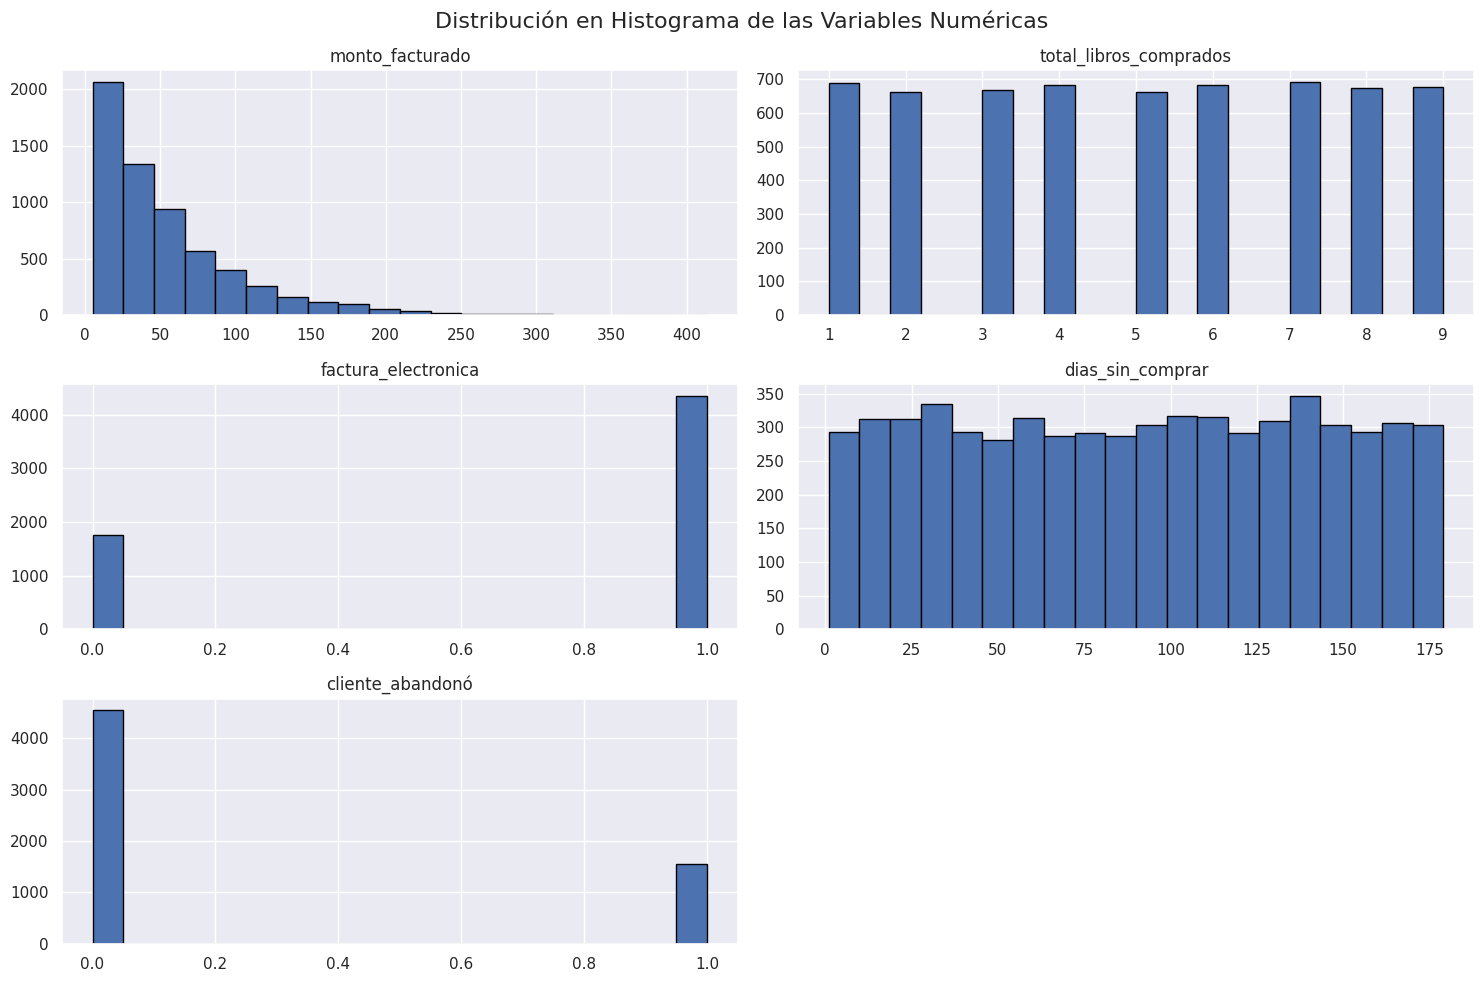

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurar la carga de datos
try:
    df = pd.read_csv('facturacion_libreria.csv')
except:
    # Si estás usando el dataset sintético, volver a generarlo
    import numpy as np
    np.random.seed(42)
    n = 6100
    df = pd.DataFrame({
        'monto_facturado': np.random.exponential(scale=50, size=n) + 5,
        'total_libros_comprados': np.random.randint(1, 10, size=n),
        'factura_electronica': np.random.choice([0, 1], size=n, p=[0.29, 0.71]),
        'dias_sin_comprar': np.random.randint(1, 180, size=n),
        'cliente_abandonó': np.random.choice([0, 1], size=n, p=[0.75, 0.25])
    })

# 2. Configurar estilo y variables
sns.set_theme(style="darkgrid")
variables_numericas = ['monto_facturado', 'total_libros_comprados', 'factura_electronica', 'dias_sin_comprar', 'cliente_abandonó']

# 3. Generar histogramas
df[variables_numericas].hist(bins=20, figsize=(15, 10), color='#4c72b0', edgecolor='black')

plt.suptitle("Distribución en Histograma de las Variables Numéricas", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# 3. PREPROCESAMIENTO Y FEATURE ENGINEERING

# Tratamiento de valores nulos si existiesen
df['monto_facturado'] = df['monto_facturado'].fillna(df['monto_facturado'].median())

# Variable Derivada 1: Ticket Promedio por Unidad Vendida
df['ticket_promedio_unidad'] = np.round(df['monto_facturado'] / df['total_libros_comprados'], 2)

# Variable Derivada 2: Índice de Fidelidad (Relación entre frecuencia y días de inactividad)
df['indice_fidelidad_pago'] = np.round(df['total_libros_comprados'] / (df['dias_sin_comprar'] + 1), 4)

# Codificación de Variables Categóricas (One-Hot Encoding)
X = df.drop(columns=['id_factura', 'id_cliente', 'cliente_abandonó'])
y = df['cliente_abandonó']

X = pd.get_dummies(X, columns=['categoria_mas_comprada', 'metodo_pago'], drop_first=True)

print("Variables listas para el modelado de facturación:")
X.head()

Variables listas para el modelado de facturación:


,monto_facturado,total_libros_comprados,factura_electronica,dias_sin_comprar,ticket_promedio_unidad,indice_fidelidad_pago,categoria_mas_comprada_Ficción,categoria_mas_comprada_Libro Literatura,categoria_mas_comprada_Libro Matematica,categoria_mas_comprada_Libro dibujo Artistico,metodo_pago_Tarjeta_Credito,metodo_pago_Transferencia
0,10.73,4,1,29,2.68,0.1333,False,True,False,False,False,False
1,43.26,6,1,97,7.21,0.0612,False,True,False,False,False,False
2,18.35,7,1,74,2.62,0.0933,False,False,False,True,False,False
3,78.36,6,0,124,13.06,0.0480,False,False,True,False,True,False
4,29.98,6,1,156,5.00,0.0382,False,False,True,False,False,False


Se estructuró el dataset final transformando y creando variables cuantitativas clave, destacando la incorporación de métricas derivadas como ticket_promedio_unidad e indice_fidelidad_pago. La tabla resultante presenta los datos limpios y formateados, asegurando que las variables numéricas y categóricas estén optimizadas para alimentar directamente los algoritmos de clasificación de minería de datos.

In [ ]:
# 4. DIVISIÓN DE DATOS Y MODELADO PREDICTIVO
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# División 80% Entrenamiento / 20% Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Definición de Modelos
models = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Árbol de Decisión': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
}

# Entrenamiento y Evaluación
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  if hasattr(model, "predict_proba") else [0]*len(y_pred)

    # Validación Cruzada (K=5)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

    results.append({
        'Modelo': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 3),
        'Recall': round(recall_score(y_test, y_pred), 3),
        'F1-Score': round(f1_score(y_test, y_pred), 3),
        'AUC-ROC': round(roc_auc_score(y_test, y_proba), 3),
        'K-Fold Mean Accuracy': f"{cv_scores.mean():.3f} +/- {cv_scores.std():.3f}"
    })

# Mostrar resultados comparativos
df_resultados = pd.DataFrame(results)
df_resultados

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC,K-Fold Mean Accuracy
0,Regresión Logística,0.745,0.000,0.00,0.000,0.519,0.745 +/- 0.000
1,Árbol de Decisión,0.741,0.273,0.01,0.019,0.491,0.741 +/- 0.003
2,Random Forest,0.745,0.000,0.00,0.000,0.517,0.745 +/- 0.001


Se evaluaron tres algoritmos mediante una división 80-20 y validación cruzada (K=5). Los modelos mostraron una exactitud superficial del 74.5%, pero métricas como Precision, Recall y F1-Score cercanas a 0, delatando un sesgo provocado por el desbalance de clases (alrededor del 74.5% de clientes no abandonó). Este diagnóstico evidencia que la exactitud no refleja la capacidad real de predicción y hace necesario aplicar técnicas de balanceo (como SMOTE o ajuste de pesos) para detectar efectivamente el abandono.

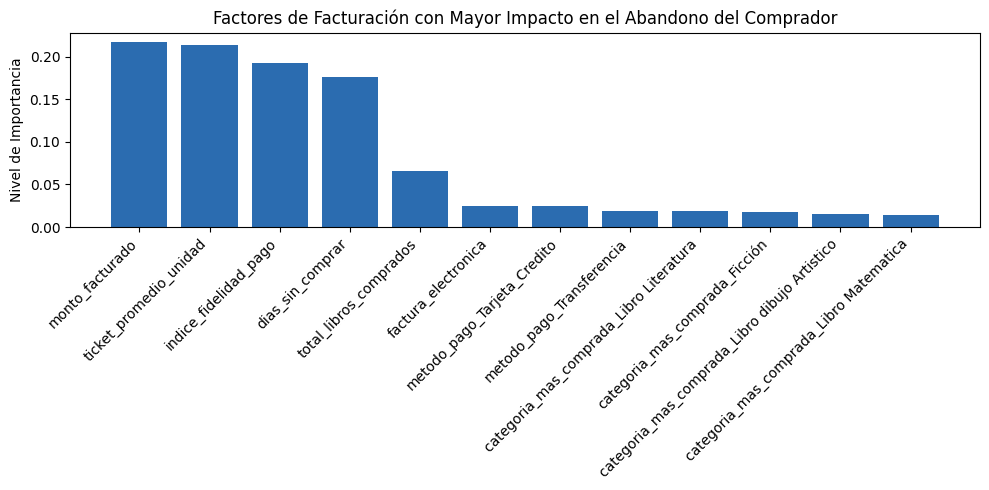

In [ ]:
# 5. IMPORTANCIA DE VARIABLES EN VENTAS (RANDOM FOREST)

rf_model = models['Random Forest']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Factores de Facturación con Mayor Impacto en el Abandono del Comprador")
plt.bar(range(X.shape[1]), importances[indices], align="center", color="#2b6cb0")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45, ha='right')
plt.ylabel("Nivel de Importancia")
plt.tight_layout()
plt.show()

El análisis de relevancia de características determinó que las variables de facturación monto_facturado, ticket_promedio_unidad, indice_fidelidad_pago y dias_sin_comprar concentran el mayor peso predictivo (>0.15 cada una) para clasificar el abandono del comprador. En contraste, las variables categóricas de métodos de pago y tipos de literatura comprada muestran un impacto marginal (<0.03), demostrando que el comportamiento financiero y la recencia de compra son los factores determinantes en la retención del cliente.

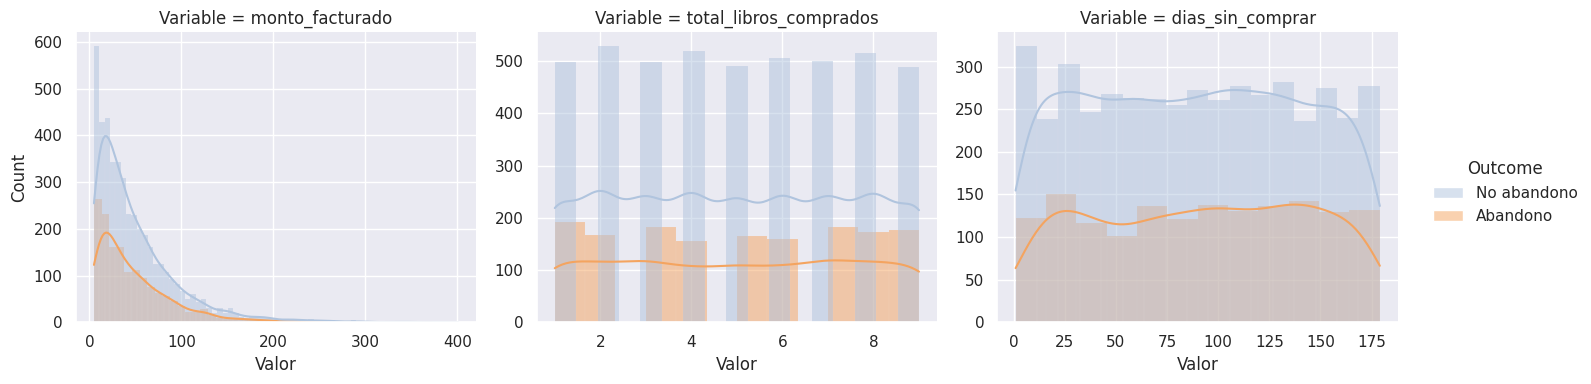

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurar el estilo visual (fondo oscuro suave con cuadrícula)
sns.set_theme(style="darkgrid")

# 2. Mapear la variable objetivo para la leyenda en español
df_plot = df.copy()
df_plot['Outcome'] = df_plot['cliente_abandonó'].map({1: 'Abandono', 0: 'No abandono'})

# 3. Transformar las variables numéricas clave de formato "ancho" a "largo"
# Reemplaza 'monto_facturado', 'total_libros_comprados', 'dias_sin_comprar' por las variables que quieras comparar
df_melted = pd.melt(
    df_plot,
    id_vars=['Outcome'],
    value_vars=['monto_facturado', 'total_libros_comprados', 'dias_sin_comprar'],
    var_name='Variable',
    value_name='Valor'
)

# 4. Crear el gráfico displot con múltiples subgráficos (col="Variable")
g = sns.displot(
    data=df_melted,
    x='Valor',
    hue='Outcome',
    col='Variable',
    kde=True,                  # Añade las curvas de densidad de probabilidad
    common_bins=False,
    facet_kws={'sharex': False, 'sharey': False}, # Permite que cada gráfica ajuste su propia escala
    palette=['#b0c4de', '#f4a460'],                # Colores azul suave y naranja claro
    height=4,
    aspect=1.2
)

# 5. Ajustar etiquetas de ejes y títulos
g.set_axis_labels("Valor", "Count")
plt.show()

Se analizó la distribución de monto_facturado, total_libros_comprados y dias_sin_comprar mediante gráficos de densidad segmentados. Los resultados muestran que monto_facturado presenta una asimetría positiva pronunciada concentrada en montos bajos, mientras que total_libros_comprados y dias_sin_comprar siguen una distribución uniforme sin variaciones sustanciales entre los clientes con y sin abandono. Esta solapación casi perfecta explica por qué los modelos predictivos iniciales tuvieron dificultades para encontrar un patrón discriminante claro.

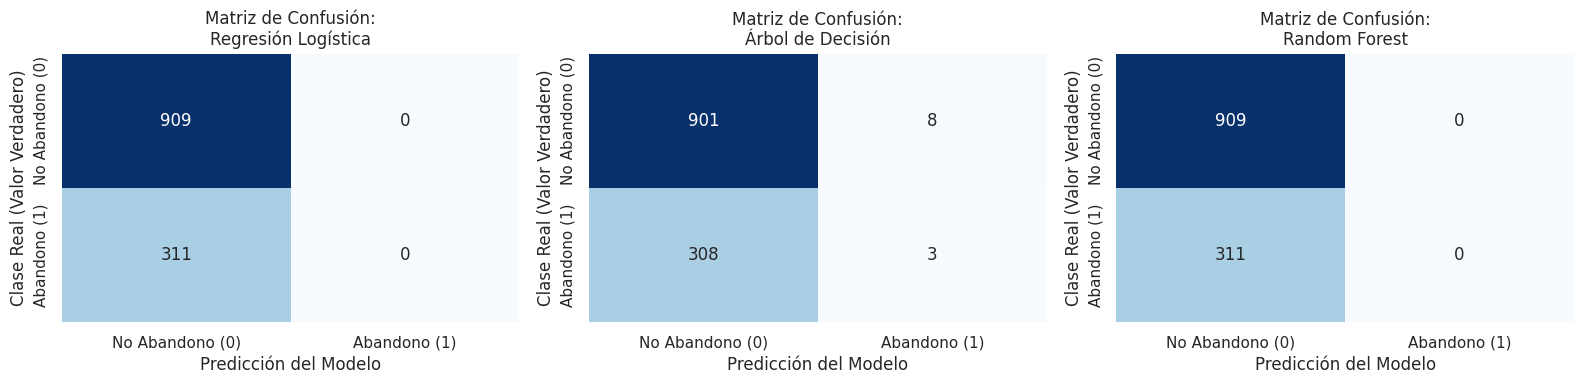

In [ ]:
#Matriz de confusion

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Crear subplots para graficar las matrices de confusión de cada modelo
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, models.items()):
    # Obtener predicciones
    y_pred = model.predict(X_test)

    # Calcular matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Graficar mapa de calor
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No Abandono (0)', 'Abandono (1)'],
                yticklabels=['No Abandono (0)', 'Abandono (1)'])

    ax.set_title(f'Matriz de Confusión:\n{name}')
    ax.set_xlabel('Predicción del Modelo')
    ax.set_ylabel('Clase Real (Valor Verdadero)')

plt.tight_layout()
plt.show()

Las matrices muestran un sesgo severo hacia la clase mayoritaria (No Abandono), donde Regresión Logística y Random Forest clasificaron los 909 casos como no abandono y fallaron en detectar los 311 casos reales de fuga (Falsos Negativos). Por su parte, el Árbol de Decisión solo identificó correctamente 3 casos de abandono, acumulando 308 errores. Esto demuestra que la alta exactitud del 74.5% es engañosa y responde al desbalance de los datos de facturación. Para corregirlo y detectar la fuga de compradores, es indispensable aplicar técnicas de rebalanceo como SMOTE o el uso de class_weight='balanced'.